In [ ]:
import _setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight

## Aerobic Exercise Protocol

### First version (S01 to S18) - Males

| Phase | RPM | Duration | Label |
|-------|-----|----------|-------|
| Warm up | - | 3:00 | REST |
| Stage 1 | 60 rpm | 3:00 | EXERCISE |
| Stage 2 | 70 rpm | 3:00 | EXERCISE |
| Stage 3 | 75 rpm | 3:00 | EXERCISE |
| Stage 4 | 80 rpm | 3:00 | EXERCISE |
| Stage 5 | 85 rpm | 3:00 | EXERCISE |
| Stage 6 | 90 rpm | 3:00 | EXERCISE |
| Stage 7 | 95 rpm | 2:00 | EXERCISE |
| Stage 8 | 100 rpm | 2:00 | EXERCISE |
| Stage 9 | 105 rpm | 2:00 | EXERCISE |
| Stage 10 | 110 rpm | 2:00 | EXERCISE |
| Cool Down | - | 4:00 | REST |
| Rest | - | 2:00 | REST |

**Total tags expected: 13** (transitions between phases)

### Second version (f01 to f13) - Females

| Phase | RPM | Duration | Label |
|-------|-----|----------|-------|
| Baseline | - | 4:30 | REST |
| Warm up | - | 2:15 | REST |
| Stage 1 | 70 rpm | 1:30 | EXERCISE |
| Stage 2 | 75 rpm | 1:30 | EXERCISE |
| Stage 3 | 80 rpm | 1:30 | EXERCISE |
| Stage 4 | 85 rpm | 11:15 | EXERCISE |
| Stage 5 | 90/95 rpm | 4:30 | EXERCISE |
| Cool Down | - | 3:00 | REST |
| Rest | - | 2:00 | REST |

**Total tags expected: 9** (transitions between phases)

**Key Differences from V1:**
- V2 includes a Baseline period (not in V1)
- V2 has fewer RPM stages but longer durations
- V2 has a very long 85 rpm phase (~11 min)
- V1 has progressive increments up to 110 rpm; V2 stops at 90/95 rpm

# Aerobic Exercise Detection from Wearable Physiological Signals

**Goal**: Build a classifier to detect aerobic exercise (high-intensity cycling) vs rest states using physiological data from wearable devices.

Build an "Exercise Detector"

1. **Collect the Signals**  
   Wearable sensors data (Empatica E4) to gather raw physiological data during cycling protocol.

2. **Label EXERCISE vs REST Periods**  
   Mark time segments where the participant was exercising at high intensity or resting.

3. **Calculate Biomarkers**
   These features help the model understand what's happening in the body:
   - **HRV (Heart Rate Variability)**  
     *How much heartbeat timing changes between beats.*  
     → **Lower during exercise** (heart becomes more "robot-like")
   - **EDA (Electrodermal Activity)**  
     *Measures sweat gland activity.*  
     → **Higher during exercise**
   - **HR (Heart Rate)**  
     *How fast the heart is beating.*  
     → **Significantly higher during exercise**
   - **ACC (Accelerometer / Movement)**  
     *Body movement from cycling.*  
     → **Higher and more rhythmic during exercise**


## Dataset Overview:
- **22 subjects** (10 males V1 protocol, 12 females V2 protocol)
- **Signals**: EDA, BVP, HR, IBI (for HRV), Temperature, Accelerometer
- **Exercise Protocol**: Progressive cycling at increasing RPM (60-110 rpm)
- **Rest Periods**: Warm up, Cool Down, Rest, Baseline

In [2]:
dataset_path = '22subjects/AEROBIC'
subject_info_path = 'WISE_data_files/subject-info.csv'

In [3]:
def create_df_array(dataframe):
    """Converts a pandas DataFrame to a flattened numpy array."""
    return dataframe.values.flatten()


def time_abs_(UTC_array):
    """Converts UTC timestamps to seconds from the start of recording."""
    new_array = []
    start_time = datetime.datetime.strptime(UTC_array[0], '%Y-%m-%d %H:%M:%S')
    
    for utc in UTC_array:
        current_time = datetime.datetime.strptime(utc, '%Y-%m-%d %H:%M:%S')
        seconds_elapsed = (current_time - start_time).total_seconds()
        new_array.append(int(seconds_elapsed))
    
    return new_array


def moving_average(acc_data):
    """
    Applies a moving average filter to accelerometer data to measure movement.
    Higher values = more movement, Lower values = less movement
    """
    avg = 0
    prevX, prevY, prevZ = 0, 0, 0
    results = []
    
    # Process every second (32 samples at 32 Hz)
    for i in range(0, len(acc_data), 32):
        sum_ = 0
        buffX = acc_data[i:i+32, 0]
        buffY = acc_data[i:i+32, 1]
        buffZ = acc_data[i:i+32, 2]
        
        for j in range(len(buffX)):
            sum_ += max(
                abs(buffX[j] - prevX),
                abs(buffY[j] - prevY),
                abs(buffZ[j] - prevZ)
            )
            prevX, prevY, prevZ = buffX[j], buffY[j], buffZ[j]
        
        avg = avg * 0.9 + (sum_ / 32) * 0.1
        results.append(avg)
    
    return results

print("Helper functions defined")

Helper functions defined


In [4]:
def read_signals(main_folder):
    """
    Each subject folder contains: EDA, BVP, HR, IBI, TEMP, ACC, tags
    """
    signal_dict = {}
    time_dict = {}
    fs_dict = {}
    
    subfolders = next(os.walk(main_folder))[1]
    
    # Get start times
    utc_start_dict = {}
    for folder_name in subfolders:
        csv_path = f'{main_folder}/{folder_name}/EDA.csv'
        df = pd.read_csv(csv_path)
        utc_start_dict[folder_name] = df.columns.tolist()
    
    # Read all signals
    for folder_name in subfolders:
        folder_path = os.path.join(main_folder, folder_name)
        files = os.listdir(folder_path)
        
        signals = {}
        time_line = {}
        fs_signal = {}
        
        desired_files = ['EDA.csv', 'BVP.csv', 'HR.csv', 'TEMP.csv', 'tags.csv', 'ACC.csv', 'IBI.csv']
        
        for file_name in files:
            if file_name not in desired_files:
                continue
            
            file_path = os.path.join(folder_path, file_name)
            signal_name = file_name.replace('.csv', '')
            
            if file_name == 'tags.csv':
                try:
                    df = pd.read_csv(file_path, header=None)
                    tags_vector = create_df_array(df)
                    tags_UTC_vector = np.insert(tags_vector, 0, utc_start_dict[folder_name])
                    signal_array = time_abs_(tags_UTC_vector)
                except pd.errors.EmptyDataError:
                    signal_array = []
            
            elif file_name == 'IBI.csv':
                df = pd.read_csv(file_path)
                signal_array = df.values
                fs_signal['IBI'] = 'variable'
            
            else:
                df = pd.read_csv(file_path)
                fs = int(df.iloc[0, 0])
                signal_array = df.iloc[1:].values
                time_array = np.linspace(0, len(signal_array)/fs, len(signal_array))
                
                time_line[signal_name] = time_array
                fs_signal[signal_name] = fs
            
            signals[signal_name] = signal_array
        
        signal_dict[folder_name] = signals
        time_dict[folder_name] = time_line
        fs_dict[folder_name] = fs_signal
    
    return signal_dict, time_dict, fs_dict

print(" Data loading function defined")

 Data loading function defined


In [5]:
# Load all physiological signals
print("Loading physiological signals...")
signal_data, time_data, fs_dict = read_signals(dataset_path)

subjects = list(signal_data.keys())
v1_subjects = sorted([s for s in subjects if s.startswith('S')])
v2_subjects = sorted([s for s in subjects if s.startswith('f')])

print(f"\n✓ Loaded {len(subjects)} subjects:")
print(f"   V1: {v1_subjects}")
print(f"   V2: {v2_subjects}")

Loading physiological signals...

✓ Loaded 22 subjects:
   V1: ['S04', 'S05', 'S08', 'S09', 'S10', 'S13', 'S14', 'S15', 'S17', 'S18']
   V2: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13']


In [6]:
# Creates time segments labeled as EXERCISE or REST based on Aerobic protocol tags.
def get_aerobic_rest_segments(subject_id, tags):
    """
    Segment the Aerobic protocol into EXERCISE vs REST periods.

    V1 (S01-S18): Warm up -> 60-110 rpm (10 phases) -> Cool Down -> Rest
    V2 (f01-f13): Baseline -> Warm up -> 70-95 rpm (5 phases) -> Cool Down -> Rest

    EXERCISE: High-intensity cycling phases (elevated HR, physical exertion)
    REST: Warm up, Cool Down, Rest, Baseline (recovery/low intensity)
    
    CORRECTED: V2 uses duration-based labeling to accurately identify the long 85 rpm phase (~675s)
    """
    segments = []
    
    if subject_id.startswith('S'):  # V1 protocol (S01-S18) - consistent structure
        if len(tags) >= 13:
            # Warm up: REST (low intensity preparation)
            segments.append({'start': tags[0], 'end': tags[1], 'label': 'REST', 'phase': 'Warm up'})
            
            # Exercise phases (60-110 rpm): EXERCISE
            rpm_phases = ['60 rpm', '70 rpm', '75 rpm', '80 rpm', '85 rpm', 
                         '90 rpm', '95 rpm', '100 rpm', '105 rpm', '110 rpm']
            for i, phase_name in enumerate(rpm_phases):
                if i + 2 < len(tags):
                    segments.append({
                        'start': tags[i + 1], 
                        'end': tags[i + 2], 
                        'label': 'EXERCISE', 
                        'phase': phase_name
                    })
            
            # Cool Down: REST
            if len(tags) >= 13:
                segments.append({'start': tags[11], 'end': tags[12], 'label': 'REST', 'phase': 'Cool Down'})
            
            # Rest: REST (if tag exists)
            if len(tags) >= 14:
                segments.append({'start': tags[12], 'end': tags[13], 'label': 'REST', 'phase': 'Rest'})
    
    else:  # V2 protocol (f01-f13) - variable structure, use duration-based labeling
        if len(tags) >= 8:
            # First, categorize all segments by duration
            # REST segments: Baseline (long), Warm up, Cool Down
            # EXERCISE segments: Short phases (70, 75, 80, 90/95 rpm ~90-250s), Long phase (85 rpm ~675s)
            
            exercise_segments = []
            
            for i in range(len(tags) - 1):
                duration = tags[i + 1] - tags[i]
                
                # Identify segment type by duration
                if i == 0:
                    # First segment is always Baseline/Warmup (REST)
                    if duration > 400:
                        # Long first segment = Baseline (possibly merged with warmup)
                        segments.append({'start': tags[i], 'end': tags[i + 1], 
                                       'label': 'REST', 'phase': 'Baseline'})
                    else:
                        segments.append({'start': tags[i], 'end': tags[i + 1], 
                                       'label': 'REST', 'phase': 'Warm up'})
                elif duration > 400:
                    # Long segment (>400s) in middle = 85 rpm sustained exercise (~675s)
                    exercise_segments.append({
                        'start': tags[i], 'end': tags[i + 1],
                        'label': 'EXERCISE', 'phase': '85 rpm (sustained)',
                        'duration': duration, 'tag_idx': i
                    })
                elif 60 <= duration <= 300:
                    # Medium segments = exercise phases or cool down
                    exercise_segments.append({
                        'start': tags[i], 'end': tags[i + 1],
                        'label': 'EXERCISE', 'phase': 'cycling',  # Will be labeled below
                        'duration': duration, 'tag_idx': i
                    })
                elif duration < 60:
                    # Very short segment - likely transition or rest
                    segments.append({'start': tags[i], 'end': tags[i + 1], 
                                   'label': 'REST', 'phase': 'Transition'})
            
            # Now label the exercise segments in order
            # Expected order: 70 rpm, 75 rpm, 80 rpm, 85 rpm (sustained), 90/95 rpm
            short_phase_labels = ['70 rpm', '75 rpm', '80 rpm', '90/95 rpm']
            short_idx = 0
            
            for seg in exercise_segments:
                if seg['phase'] == '85 rpm (sustained)':
                    segments.append({
                        'start': seg['start'], 'end': seg['end'],
                        'label': 'EXERCISE', 'phase': '85 rpm (sustained)'
                    })
                elif seg['phase'] == 'cycling':
                    # Check if this might be Cool Down (typically at end, ~180s)
                    # Cool down is usually the last medium-length segment
                    if short_idx >= len(short_phase_labels):
                        segments.append({
                            'start': seg['start'], 'end': seg['end'],
                            'label': 'REST', 'phase': 'Cool Down'
                        })
                    else:
                        segments.append({
                            'start': seg['start'], 'end': seg['end'],
                            'label': 'EXERCISE', 'phase': short_phase_labels[short_idx]
                        })
                        short_idx += 1
            
            # Sort segments by start time
            segments.sort(key=lambda x: x['start'])
    
    return segments

print("Segmentation function defined (CORRECTED for V2 duration-based labeling)")

Segmentation function defined (CORRECTED for V2 duration-based labeling)


---
### Segmentation

`get_aerobic_rest_segments(subject_id, tags)`
- Divides protocol into EXERCISE vs REST periods
- Uses tag timestamps to identify phase transitions
- V1 has 13 tags (12 transitions), V2 has 9 tags (8 transitions)

In [7]:
# Create segments for all subjects
all_segments = {}
for subject in subjects:
    tags = signal_data[subject]['tags']
    if len(tags) > 0:
        segments = get_aerobic_rest_segments(subject, tags)
        all_segments[subject] = segments

# Show example for one V1 and one V2 subject
print(f"Example V1 subject - {v1_subjects[0]}:")
print(f"  Tags available: {len(signal_data[v1_subjects[0]]['tags'])}")
for seg in all_segments.get(v1_subjects[0], []):
    dur = seg['end'] - seg['start']
    print(f"  {seg['label']:8s} {seg['phase']:15s} {seg['start']:4d}-{seg['end']:4d}s ({dur}s)")

print(f"\nExample V2 subject - {v2_subjects[0]}:")
print(f"  Tags available: {len(signal_data[v2_subjects[0]]['tags'])}")
for seg in all_segments.get(v2_subjects[0], []):
    dur = seg['end'] - seg['start']
    print(f"  {seg['label']:8s} {seg['phase']:15s} {seg['start']:4d}-{seg['end']:4d}s ({dur}s)")

Example V1 subject - S04:
  Tags available: 13
  REST     Warm up            0- 183s (183s)
  EXERCISE 60 rpm           183- 366s (183s)
  EXERCISE 70 rpm           366- 541s (175s)
  EXERCISE 75 rpm           541- 721s (180s)
  EXERCISE 80 rpm           721- 901s (180s)
  EXERCISE 85 rpm           901-1081s (180s)
  EXERCISE 90 rpm          1081-1206s (125s)
  EXERCISE 95 rpm          1206-1320s (114s)
  EXERCISE 100 rpm         1320-1440s (120s)
  EXERCISE 105 rpm         1440-1561s (121s)
  EXERCISE 110 rpm         1561-1684s (123s)
  REST     Cool Down       1684-1916s (232s)

Example V2 subject - f01:
  Tags available: 9
  REST     Baseline           0- 686s (686s)
  EXERCISE 70 rpm           686- 808s (122s)
  EXERCISE 75 rpm           808- 921s (113s)
  EXERCISE 80 rpm           921-1046s (125s)
  EXERCISE 85 rpm (sustained) 1046-1761s (715s)
  EXERCISE 90/95 rpm       1761-1950s (189s)
  REST     Cool Down       1950-2169s (219s)
  REST     Cool Down       2169-2291s (122s)


### V1 Tag Mapping (S01-S18)

| Tag Index | Phase Transition | Label |
|-----------|------------------|-------|
| 0 → 1 | Start → End Warm up | REST |
| 1 → 2 | 60 rpm | EXERCISE |
| 2 → 3 | 70 rpm | EXERCISE |
| 3 → 4 | 75 rpm | EXERCISE |
| 4 → 5 | 80 rpm | EXERCISE |
| 5 → 6 | 85 rpm | EXERCISE |
| 6 → 7 | 90 rpm | EXERCISE |
| 7 → 8 | 95 rpm | EXERCISE |
| 8 → 9 | 100 rpm | EXERCISE |
| 9 → 10 | 105 rpm | EXERCISE |
| 10 → 11 | 110 rpm | EXERCISE |
| 11 → 12 | Cool Down | REST |
| 12 → 13 | Rest (if exists) | REST |

### V2 Tag Mapping (f01-f13) - CORRECTED

**Note:** V2 has variable tag structure across subjects. The code now uses **duration-based labeling** to correctly identify phases:

| Duration | Phase | Label |
|----------|-------|-------|
| >400s (first segment) | Baseline (may include Warmup) | REST |
| 90-200s (first few) | 70, 75, 80 rpm | EXERCISE |
| 500-800s | **85 rpm (sustained)** - the long phase | EXERCISE |
| 90-200s (after 85 rpm) | 90/95 rpm | EXERCISE |
| 100-250s (last) | Cool Down | REST |

**Key Insight:** The V2 protocol has a very long 85 rpm phase (~11 minutes / 675s). 
Previous hardcoded indices mislabeled this phase. Duration-based detection is more robust.

---
### Visualize Raw Signals

In [8]:
# Plotting function to visualize all physiological signals for one subject.
def plot_subject_signals(subject_id, signals, time_dict, tags, state='AEROBIC'):
    """
    Plot all physiological signals for one subject.
    Highlights EXERCISE periods with colored shading to verify segmentation.
    """
    plt.figure(figsize=(20, 12))
    
    signal_names = ['EDA', 'BVP', 'HR', 'TEMP', 'ACC']
    available_signals = [s for s in signal_names if s in signals and s in time_dict]
    
    for i, signal_name in enumerate(available_signals, 1):
        plt.subplot(len(available_signals), 1, i)
        
        if i == 1:
            plt.title(f'{subject_id} - {state} Protocol (Raw Signals)',
                     fontsize=16, fontweight='bold', pad=10)
        
        # Plot signal
        if signal_name == 'ACC':
            acc_filtered = moving_average(signals[signal_name])
            plt.plot(acc_filtered, label=signal_name, linewidth=1, color='purple')
        else:
            plt.plot(time_dict[signal_name], signals[signal_name],
                    label=signal_name, linewidth=1)
        
        # Add tag markers (red vertical lines)
        for j, tag in enumerate(tags[1:], 1):
            plt.axvline(x=tag, color='red', linestyle='--', alpha=0.5, linewidth=1)
        
        # Highlight EXERCISE periods with colored regions
        if state == 'AEROBIC' and len(tags) > 0:
            if subject_id.startswith('S'):  # V1 protocol
                if len(tags) >= 13:
                    # Color gradient for increasing intensity
                    colors = plt.cm.Oranges(np.linspace(0.3, 0.9, 10))
                    rpm_labels = ['60', '70', '75', '80', '85', '90', '95', '100', '105', '110']
                    for idx in range(10):
                        if idx + 2 < len(tags):
                            plt.axvspan(tags[idx + 1], tags[idx + 2], 
                                       color=colors[idx], alpha=0.3,
                                       label=f'{rpm_labels[idx]} rpm' if i == 1 else '')
            else:  # V2 protocol
                if len(tags) >= 8:
                    # Exercise phases for V2
                    exercise_phases = [
                        (2, 3, 'orange', '70 rpm'),
                        (3, 4, 'darkorange', '75 rpm'),
                        (4, 5, 'orangered', '80 rpm'),
                        (5, 6, 'red', '85 rpm'),
                        (6, 7, 'darkred', '90/95 rpm')
                    ]
                    for start_idx, end_idx, color, label in exercise_phases:
                        if end_idx < len(tags):
                            plt.axvspan(tags[start_idx], tags[end_idx], 
                                       color=color, alpha=0.2,
                                       label=label if i == 1 else '')

        plt.ylabel(signal_name, fontsize=11, fontweight='bold')
        plt.grid(True, alpha=0.3)
        if i == 1:
            plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), 
                      fontsize=9, framealpha=0.95, borderaxespad=0)
    
    plt.xlabel('Time (seconds)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Plotting function defined")

Plotting function defined


- **V1 (males):** S04, S05, S08, S09, S10, S13, S14, S15, S17, S18
- **V2 (females):** f01, f02, f03, f04, f05, f06, f08, f09, f10, f11, f12, f13

- Red dashed lines: Protocol transition markers (tags)
- Orange shading: Exercise periods at various RPM intensities
- EDA (top): Look for sweat response during exercise
- HR (middle): Should show elevated heart rate during exercise phases
- ACC (bottom): Rhythmic movement patterns from cycling
- Goal: verify that exercise periods show physiological changes

Visualizing subject: S04
Protocol: V1 (males, 60-110 rpm)



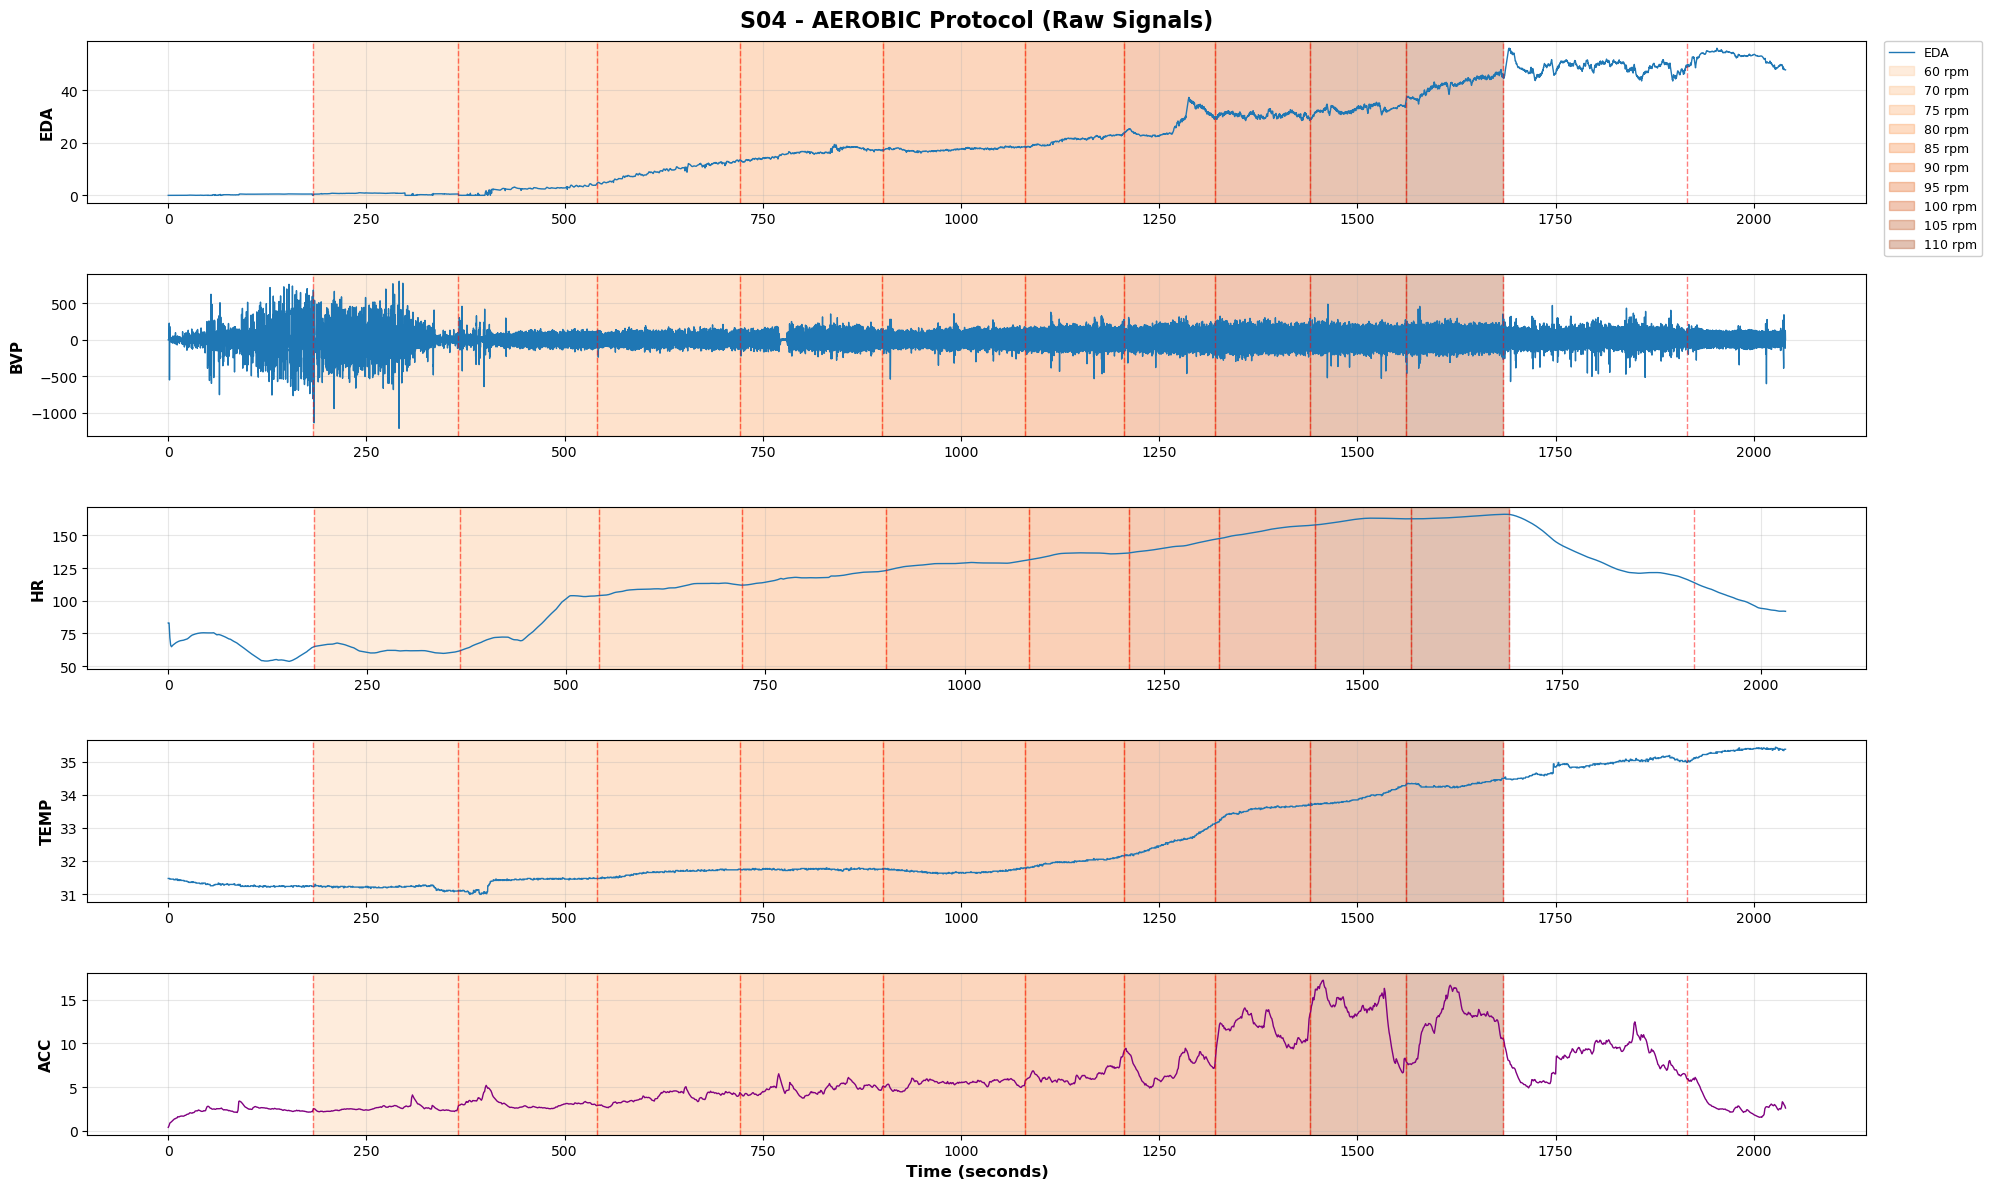

In [9]:
# Specify subject id to visualize
subject_id = 'S04'  # Options: S04, S05, S08, S09, S10, S13, S14, S15, S17, S18, f01-f13

# Plot the selected subject
if subject_id in signal_data:
    print(f"Visualizing subject: {subject_id}")
    protocol = "V1 (males, 60-110 rpm)" if subject_id.startswith('S') else "V2 (females, 70-95 rpm)"
    print(f"Protocol: {protocol}\n")
    
    plot_subject_signals(
        subject_id,
        signal_data[subject_id],
        time_data[subject_id],
        signal_data[subject_id]['tags'],
        state='AEROBIC'
    )
else:
    print(f"Subject '{subject_id}' not found!")
    print(f"Available subjects: {subjects}")

Protocol: V2 (females, 70-95 rpm)



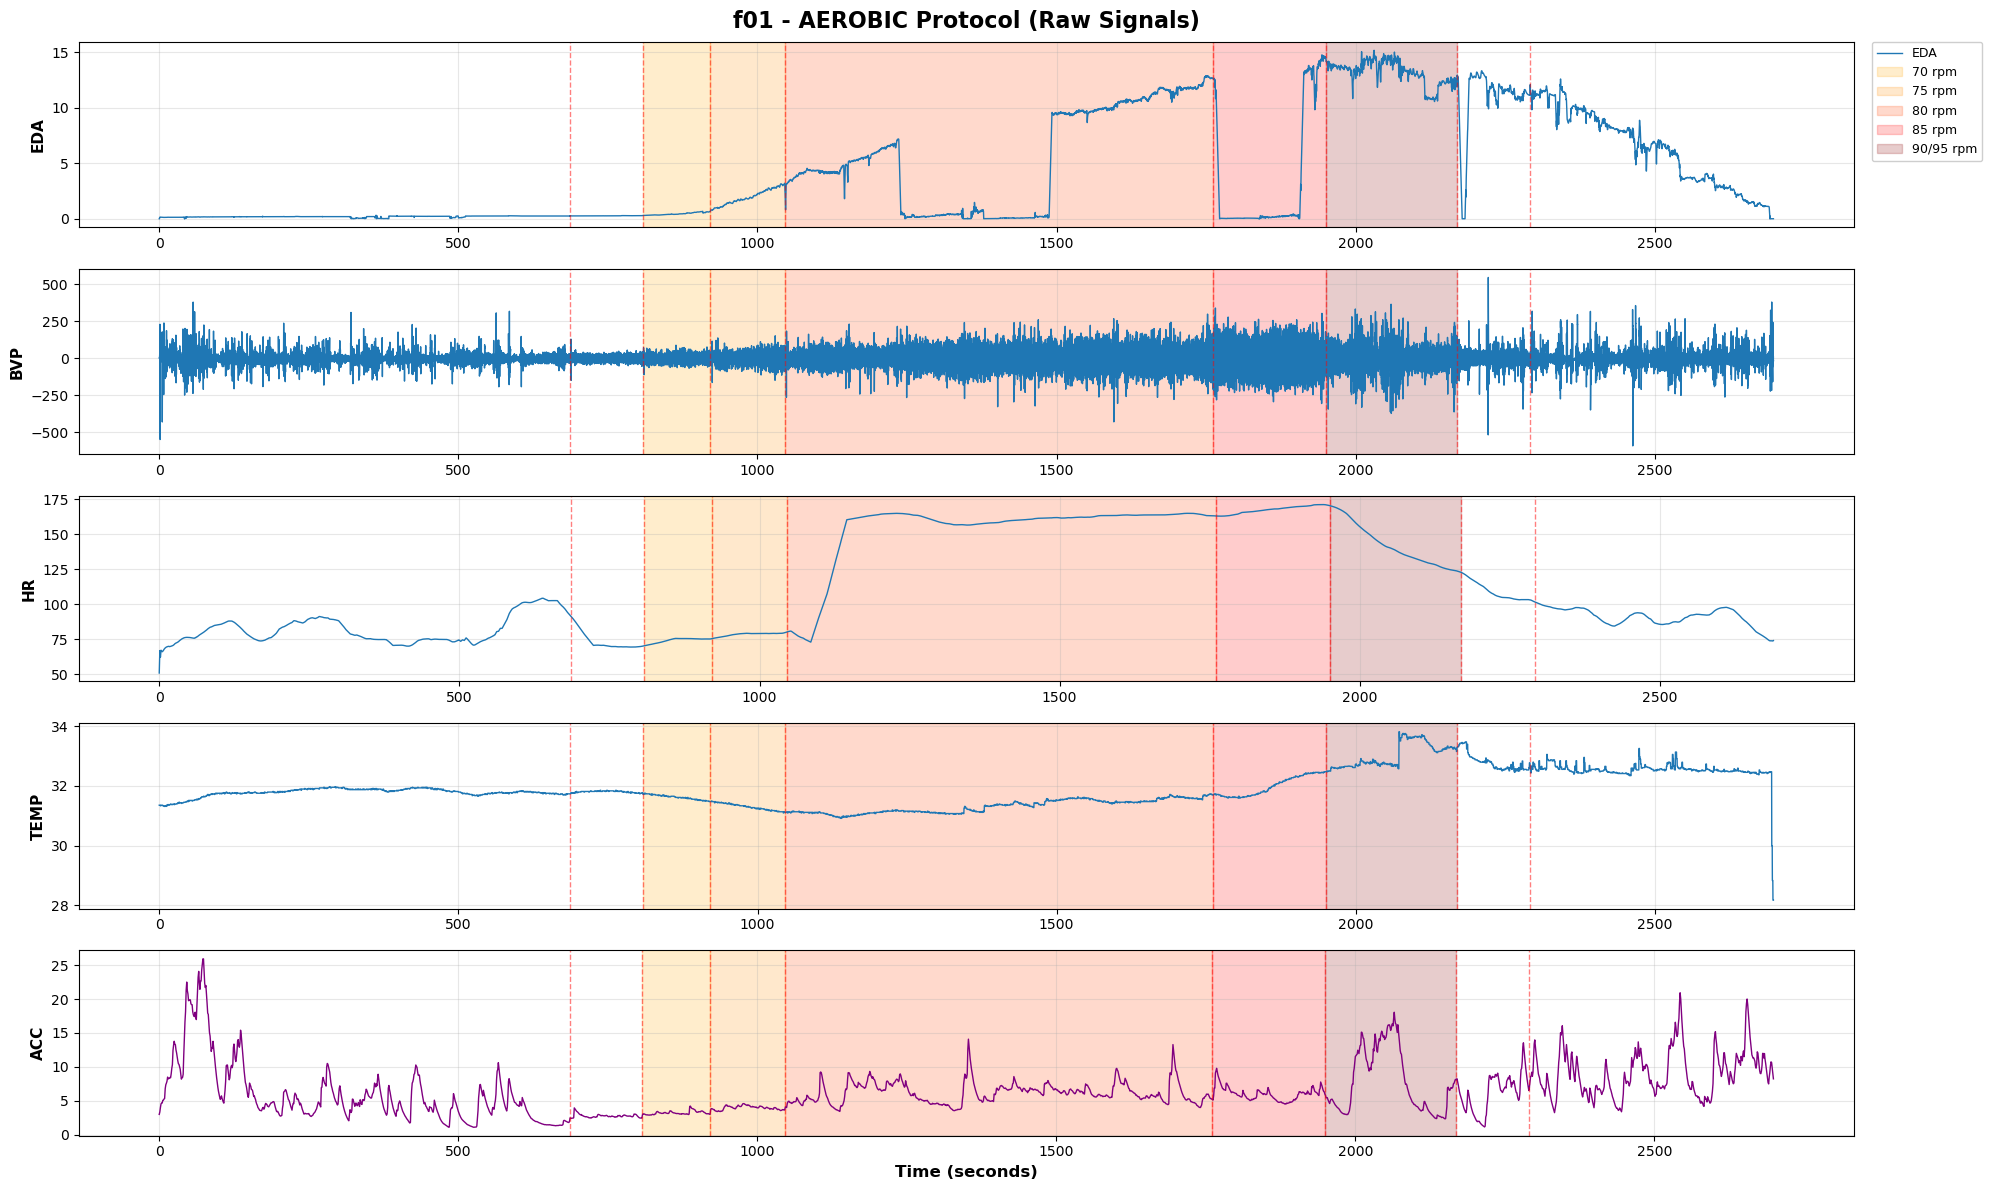

In [10]:
# PLOT FOR V2 Subject (female)
subject_f01 = 'f01'
protocol = "V1 (males, 60-110 rpm)" if subject_f01.startswith('S') else "V2 (females, 70-95 rpm)"
print(f"Protocol: {protocol}\n")

plot_subject_signals(
    subject_f01,
    signal_data[subject_f01],
    time_data[subject_f01],
    signal_data[subject_f01]['tags'],
    state='AEROBIC'
)

----

## Calculate Biomarkers (Features)

### Heart Rate Variability (HRV) Function

We need calculate two main HRV metrics from the IBI (inter-beat interval) signal:

##### 1. **SDNN** — Overall Heartbeat Variability  
**SDNN = standard deviation of the IBI values**
- Overall heartbeat variability across the entire segment
- Measures how much your heartbeat timing *changes in general*.
- Think of your heartbeat like footsteps:
  - **Resting:** footsteps naturally speed up and slow down → **high SDNN**
  - **Exercising:** footsteps are evenly spaced like a metronome → **low SDNN**

##### 2. **RMSSD** — Beat-to-Beat Variability 
- Beat-to-beat variability (short-term changes)
- More sensitive to rapid changes than SDNN
**RMSSD = root mean square of the differences between consecutive IBIs**

HRV is one of the most reliable exercise intensity biomarkers
- During high-intensity exercise, the sympathetic nervous system dominates → reduced variability
- High HRV (REST): Parasympathetic dominance = healthy variability
- Low HRV (EXERCISE): Sympathetic dominance = rigid heart rate

In [11]:
# calculate_hrv(ibi_data, start_time, end_time)
# - Calculates Heart Rate Variability metrics:
# - SDNN: Standard deviation of IBI intervals (overall HRV)
# - RMSSD: Root mean square of successive differences (short-term HRV)
# -> Lower HRV = Higher exercise intensity

def calculate_hrv(ibi_data, start_time, end_time):
    """Calculate HRV: Lower HRV = More Intense Exercise"""
    if len(ibi_data) == 0:
        return {'SDNN': np.nan, 'RMSSD': np.nan}
    # 1. Filter IBI data for the time segment
    timestamps = ibi_data[:, 0]
    ibi_values = ibi_data[:, 1]
    mask = (timestamps >= start_time) & (timestamps <= end_time)
    segment_ibi = ibi_values[mask]
    
    if len(segment_ibi) < 2:
        return {'SDNN': np.nan, 'RMSSD': np.nan}
    # 2. Calculate SDNN (Standard Deviation of NN intervals)
    sdnn = np.std(segment_ibi)
    # 3. Calculate RMSSD (Root Mean Square of Successive Differences)
    rmssd = np.sqrt(np.mean(np.diff(segment_ibi)**2))  # Short-term HRV
    
    return {'SDNN': sdnn, 'RMSSD': rmssd}

print("HRV calculation function defined")

HRV calculation function defined


### Extract Features from Each Segment
- **IBI (HRV)**: SDNN, RMSSD (2 features)
- **EDA**: mean, std, max (3 features)
- **HR**: mean, std, max (3 features)
- **TEMP**: mean, std (2 features)
- **ACC**: mean, std (2 features)

Feature Extraction: `extract_segment_features()`
- Converts raw time series samples → 16 numbers
- Mean HR = average cardiovascular load
- HRV RMSSD = autonomic nervous system flexibility
- EDA std = sweat response variability

In [12]:
def extract_segment_features(subject, segment, signals, fs_dict):
    """Extract all biomarkers for one segment"""
    features = {
        'subject': subject,
        'label': segment['label'],
        'phase': segment['phase'],
        'duration': segment['end'] - segment['start']
    }
    
    start_t, end_t = segment['start'], segment['end']
    
    # HRV
    if 'IBI' in signals and len(signals['IBI']) > 0:
        hrv = calculate_hrv(signals['IBI'], start_t, end_t)
        features.update(hrv)
    else:
        features.update({'SDNN': np.nan, 'RMSSD': np.nan})
    
    # EDA
    if 'EDA' in signals:
        fs = fs_dict[subject]['EDA']
        idx_start, idx_end = int(start_t * fs), int(end_t * fs)
        eda = signals['EDA'][idx_start:idx_end].flatten()
        features['EDA_mean'] = np.mean(eda)
        features['EDA_std'] = np.std(eda)
        features['EDA_max'] = np.max(eda)
    
    # HR
    if 'HR' in signals:
        fs = fs_dict[subject]['HR']
        idx_start, idx_end = int(start_t * fs), int(end_t * fs)
        hr = signals['HR'][idx_start:idx_end].flatten()
        features['HR_mean'] = np.mean(hr)
        features['HR_std'] = np.std(hr)
        features['HR_max'] = np.max(hr)
    
    # Temperature
    if 'TEMP' in signals:
        fs = fs_dict[subject]['TEMP']
        idx_start, idx_end = int(start_t * fs), int(end_t * fs)
        temp = signals['TEMP'][idx_start:idx_end].flatten()
        features['TEMP_mean'] = np.mean(temp)
        features['TEMP_std'] = np.std(temp)
    
    # Accelerometer
    if 'ACC' in signals:
        fs = fs_dict[subject]['ACC']
        idx_start, idx_end = int(start_t * fs), int(end_t * fs)
        acc = signals['ACC'][idx_start:idx_end]
        acc_filtered = moving_average(acc)
        features['ACC_mean'] = np.mean(acc_filtered)
        features['ACC_std'] = np.std(acc_filtered)
    
    return features

print("Feature extraction function defined")

Feature extraction function defined


In [13]:
# Extract features for all segments
all_features = []

for subject in subjects:
    if subject in all_segments:
        for segment in all_segments[subject]:
            feat = extract_segment_features(subject, segment, signal_data[subject], fs_dict)
            all_features.append(feat)

df_features = pd.DataFrame(all_features)

print(f"\n✓ Extracted {len(df_features)} segments")
print(f"   EXERCISE: {len(df_features[df_features['label']=='EXERCISE'])}")
print(f"   REST: {len(df_features[df_features['label']=='REST'])}")
print(f"\nColumns: {list(df_features.columns)}")
df_features


✓ Extracted 216 segments
   EXERCISE: 163
   REST: 53

Columns: ['subject', 'label', 'phase', 'duration', 'SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'EDA_max', 'HR_mean', 'HR_std', 'HR_max', 'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']


,subject,label,phase,duration,SDNN,RMSSD,EDA_mean,EDA_std,EDA_max,HR_mean,HR_std,HR_max,TEMP_mean,TEMP_std,ACC_mean,ACC_std
0,S05,REST,Warm up,179,0.038478,0.036192,8.018124,2.808028,11.788278,84.935866,5.809791,109.00,32.952402,1.332195,3.754142,1.199980
1,S05,EXERCISE,60 rpm,181,0.034849,0.034407,14.249893,1.799457,17.542082,86.233094,1.119076,88.45,32.145967,0.708404,2.435399,0.523971
2,S05,EXERCISE,70 rpm,178,0.040973,0.056194,17.684594,0.962079,19.483345,91.069438,1.118163,93.37,32.514607,0.542668,3.367891,0.761263
3,S05,EXERCISE,75 rpm,173,0.030970,0.031417,16.111143,0.932511,17.954628,94.653931,2.628210,98.03,32.102659,0.651120,4.349853,0.868041
4,S05,EXERCISE,80 rpm,184,0.030127,0.045630,16.123037,0.847038,18.655771,101.659511,2.072372,103.83,32.657065,0.462970,5.633086,1.296311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,f06,EXERCISE,80 rpm,106,0.016570,0.014898,15.710222,1.187054,18.934221,168.885660,8.840862,181.33,34.089340,0.371867,4.032372,1.974258
212,f06,EXERCISE,85 rpm (sustained),710,0.044273,0.038937,25.921879,11.647013,45.048958,175.794324,8.885467,182.88,35.328056,0.701708,6.330838,1.721187
213,f06,REST,Transition,9,0.011382,0.018815,36.369019,0.265014,36.780598,156.462222,0.506091,157.25,35.965556,0.022662,0.973284,0.450279
214,f06,EXERCISE,90/95 rpm,111,0.028334,0.039572,34.232473,3.653431,40.044449,144.265045,5.831479,155.48,35.788468,0.177506,4.028525,3.426230


Note: There appears to be a class imbalance (163 EXERCISE instances and 53 REST instance)

### Random Forest

In [15]:
# Prepare data for Random Forest classifier
X = df_features.drop(columns=['subject', 'label', 'phase', 'duration'])
y = df_features['label']

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42, stratify=y)

# Create and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

Random Forest Classification Report:
              precision    recall  f1-score   support

    EXERCISE       0.83      0.91      0.87        33
        REST       0.62      0.45      0.53        11

    accuracy                           0.80        44
   macro avg       0.73      0.68      0.70        44
weighted avg       0.78      0.80      0.78        44


Confusion Matrix:
[[30  3]
 [ 6  5]]

Top 10 Important Features:
      feature  importance
6      HR_std    0.243781
10   ACC_mean    0.120936
11    ACC_std    0.115472
8   TEMP_mean    0.080216
7      HR_max    0.069731
5     HR_mean    0.064734
1       RMSSD    0.063031
2    EDA_mean    0.059085
0        SDNN    0.050811
4     EDA_max    0.049877


### AdaBoost

In [16]:
# compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = dict(zip(np.unique(y), class_weights))
#print(f"Class weights: {class_weight_dict}\n")

# train
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
sample_weights = np.array([class_weight_dict[label] for label in y_train]) # for class imbalance
ada_model.fit(X_train, y_train, sample_weight=sample_weights)

# evaluate
y_pred_ada = ada_model.predict(X_test)
print("AdaBoost Classification Report:")
print(classification_report(y_test, y_pred_ada))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))

#feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': ada_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 10 Important Features:")
print(feature_importance.head(10))

AdaBoost Classification Report:
              precision    recall  f1-score   support

    EXERCISE       0.85      0.88      0.87        33
        REST       0.60      0.55      0.57        11

    accuracy                           0.80        44
   macro avg       0.73      0.71      0.72        44
weighted avg       0.79      0.80      0.79        44


Confusion Matrix:
[[29  4]
 [ 5  6]]

Top 10 Important Features:
      feature  importance
10   ACC_mean    0.164238
11    ACC_std    0.128683
7      HR_max    0.125818
1       RMSSD    0.114264
6      HR_std    0.105226
8   TEMP_mean    0.085354
3     EDA_std    0.073514
5     HR_mean    0.072703
2    EDA_mean    0.050639
0        SDNN    0.046282


### XGBoost

In [17]:
# encode labels to 0 & 1 (exercise -> 0, rest -> 1, bc LabelEncoder encodes alphabetically)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
print(f"Label encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
n_class_0 = len(y_train_encoded[y_train_encoded == 0])
n_class_1 = len(y_train_encoded[y_train_encoded == 1])
scale_pos_weight = n_class_0 / n_class_1
print(f"scale_pos_weight: {scale_pos_weight:.4f}")
print(f"Class 0 count (train set): {n_class_0}, Class 1 count (train set): {n_class_1}\n")

# train
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale_pos_weight, # for class imbalance
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train_encoded)

# evaluate
y_pred_xgb_encoded = xgb_model.predict(X_test)

# convert predictions back to original labels 
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

#feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 10 Important Features:")
print(feature_importance.head(10))

Label encoding: {'EXERCISE': 0, 'REST': 1}
scale_pos_weight: 3.0952
Class 0 count (train set): 130, Class 1 count (train set): 42

XGBoost Classification Report:
              precision    recall  f1-score   support

    EXERCISE       0.87      0.82      0.84        33
        REST       0.54      0.64      0.58        11

    accuracy                           0.77        44
   macro avg       0.70      0.73      0.71        44
weighted avg       0.79      0.77      0.78        44


Confusion Matrix:
[[27  6]
 [ 4  7]]

Top 10 Important Features:
      feature  importance
6      HR_std    0.366343
11    ACC_std    0.108933
7      HR_max    0.093512
10   ACC_mean    0.072872
2    EDA_mean    0.069463
5     HR_mean    0.066084
4     EDA_max    0.049275
9    TEMP_std    0.047277
3     EDA_std    0.036381
8   TEMP_mean    0.035583


### Support Vector Classifier

In [22]:
# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train
svc_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)
svc_model.fit(X_train_scaled, y_train)

# evaluate
y_pred_svc = svc_model.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred_svc))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))

#feature importance
perm_importance = permutation_importance(
    svc_model,
    X_test_scaled,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring='f1_macro'
)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

Classification Report:
              precision    recall  f1-score   support

    EXERCISE       0.87      0.82      0.84        33
        REST       0.54      0.64      0.58        11

    accuracy                           0.77        44
   macro avg       0.70      0.73      0.71        44
weighted avg       0.79      0.77      0.78        44


Confusion Matrix:
[[27  6]
 [ 4  7]]

Top 10 Important Features:
      feature  importance
7      HR_max    0.100088
10   ACC_mean    0.069070
11    ACC_std    0.034811
3     EDA_std    0.005538
6      HR_std    0.004164
8   TEMP_mean    0.000000
9    TEMP_std    0.000000
0        SDNN   -0.004671
1       RMSSD   -0.021883
5     HR_mean   -0.024381


## Feauture Importance Comparison

In [23]:
def normalize_importance(values, method="sum1"):
    values = np.array(values, dtype=float)
    
    # absolute values are taken, then everything sums to 1 (for svc's perumutatation importance)
    if method == "sum1_abs":
        denom = np.sum(np.abs(values))
        return np.abs(values) / denom if denom != 0 else values
    
    # all importances are non-negative and add up to 1 (for rf, adaboost, xgboost)
    elif method == "sum1":
        values = np.clip(values, 0, None) 
        denom = np.sum(values)
        return values / denom if denom != 0 else values
    
    # the largest absolute importance becomes 1 (relative scaling for visualization)
    elif method == "max1":
        denom = np.max(np.abs(values))
        return values / denom if denom != 0 else values

In [31]:
rf_importance = pd.Series(normalize_importance(rf_model.feature_importances_, "sum1"), index=X.columns, name="Random Forest")
ada_importance = pd.Series(normalize_importance(ada_model.feature_importances_, "sum1"), index=X.columns, name="AdaBoost")
xgb_importance = pd.Series(normalize_importance(xgb_model.feature_importances_, "sum1"), index=X.columns, name="XGBoost")
svc_importance = pd.Series(normalize_importance(perm_importance.importances_mean, "sum1_abs"), index=X.columns, name="Support Vector Classifier")

#### Normalized feature importance: How much does each model rely on each feature?

In [32]:
normalized_importance_table = pd.concat([rf_importance, ada_importance, xgb_importance, svc_importance], axis=1)
normalized_importance_table["Mean Importance"] = normalized_importance_table.mean(axis=1)
normalized_importance_table = normalized_importance_table.sort_values("Mean Importance", ascending=False)
normalized_importance_table

,Random Forest,AdaBoost,XGBoost,Support Vector Classifier,Mean Importance
HR_std,0.243781,0.105226,0.366343,0.013199,0.182137
HR_max,0.069731,0.125818,0.093512,0.317238,0.151575
ACC_mean,0.120936,0.164238,0.072872,0.218923,0.144242
ACC_std,0.115472,0.128683,0.108933,0.110338,0.115856
HR_mean,0.064734,0.072703,0.066084,0.077279,0.070200
RMSSD,0.063031,0.114264,0.027164,0.069359,0.068454
EDA_mean,0.059085,0.050639,0.069463,0.080965,0.065038
TEMP_mean,0.080216,0.085354,0.035583,0.000000,0.050288
EDA_max,0.049877,0.012304,0.049275,0.080343,0.047950
EDA_std,0.033929,0.073514,0.036381,0.017552,0.040344


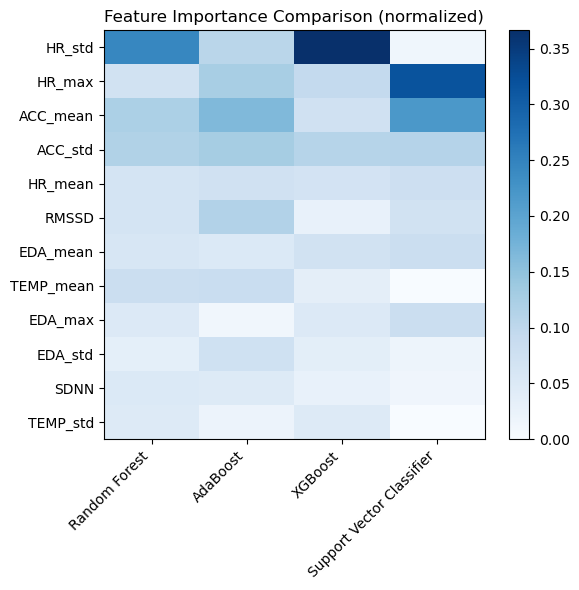

In [33]:
mat = normalized_importance_table.drop(columns=["Mean Importance"])
plt.figure(figsize=(6, 6))
plt.imshow(mat.values, aspect="auto", cmap="Blues")
plt.yticks(range(len(mat.index)), mat.index)
plt.xticks(range(len(mat.columns)), mat.columns, rotation=45, ha="right")
plt.colorbar()
plt.title("Feature Importance Comparison (normalized)")
plt.tight_layout()
plt.show()

#### Feature importances ranked: which features are consistently important across different models?

In [34]:
ranked_importance_table = normalized_importance_table.rank(ascending=False, method="average")
ranked_importance_table["Mean_rank"] = ranked_importance_table.mean(axis=1)
ranked_importance_table = ranked_importance_table.sort_values("Mean_rank")

ranked_importance_table


,Random Forest,AdaBoost,XGBoost,Support Vector Classifier,Mean Importance,Mean_rank
ACC_mean,2.0,1.0,4.0,2.0,3.0,2.4
HR_max,5.0,3.0,3.0,1.0,2.0,2.8
ACC_std,3.0,2.0,2.0,3.0,4.0,2.8
HR_std,1.0,5.0,1.0,10.0,1.0,3.6
HR_mean,6.0,8.0,6.0,6.0,5.0,6.2
EDA_mean,8.0,9.0,5.0,4.0,7.0,6.6
RMSSD,7.0,4.0,11.0,7.0,6.0,7.0
TEMP_mean,4.0,6.0,10.0,11.5,8.0,7.9
EDA_max,10.0,12.0,7.0,5.0,9.0,8.6
EDA_std,12.0,7.0,9.0,8.0,10.0,9.2


The normalized feature importance table shows how strongly each model relies on individual features, and the ranked feature importance table captures consistency of feature relevance across models. A strong feature is high mean importance and low mean rank (rank 1 = most important feature). It appears **heart rate variability (HR_std)** and **accelerometer-based features (ACC_mean, ACC_std)** consistently indicate robust predictive value. Interestingly, **RMSSD** is ranked first for AdaBoost but last for XGBoost, so it is highly informative for some models but not robust across all models.  **EDA-derived** features show moderate importance and greater variability across models. **EDA_max and SDNN** rank consistently low. 

Note: these feature importances reflect how models utilize features for prediction and do not imply causal relationships so these results should be interpreted as model/dataset-specific indicators of usefulness rather than definitive measures of physiological importance.